<a href="https://colab.research.google.com/github/leeand2025/credit-card-clustering/blob/main/lien_tugas_unsupervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UNSUPERVISED LEARNING - BASIC CLUSTERING
---

<b>Pemateri:</b>
- Teguh Prasetyo
- Wishnu KA Erlangga

**Ministry of Finance - Data Analytics Community**
---

---





## 0. Peta pembelajaran

### Apa yang berbeda dari supervised learning?

- **Supervised:** kita punya target/label `y` dan ingin memprediksi target tersebut.
- **Unsupervised:** kita **tidak punya target**. Kita mencari pola atau kelompok yang secara karakteristik mirip.

### Flow dasar clustering

**Business question → pilih unit analisis → pilih fitur/variabel yang relevan → cek data → scaling → bentuk cluster → evaluasi → profiling cluster → business insight**

> **Mindset penting:** algoritma menemukan pola, tetapi **manusia yang memberi makna** pada pola tersebut.

In [2]:
# standard ML library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# evaluation
# elbow method

# model
from sklearn.cluster import DBSCAN, KMeans

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
print("Library siap digunakan.")

Library siap digunakan.


In [3]:
# jika menggunakan google colab dan butuh upload file csv

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Ilustrasi intuisi: bagaimana data bisa “terkelompok”?

Sebelum membaca dataset nyata, lihat contoh sederhana. Anggap setiap titik adalah satu objek. Kita belum memberi nama kelompoknya. Mata kita dapat melihat beberapa kelompok; algoritma clustering mencoba melakukan hal yang sama dengan aturan matematis.

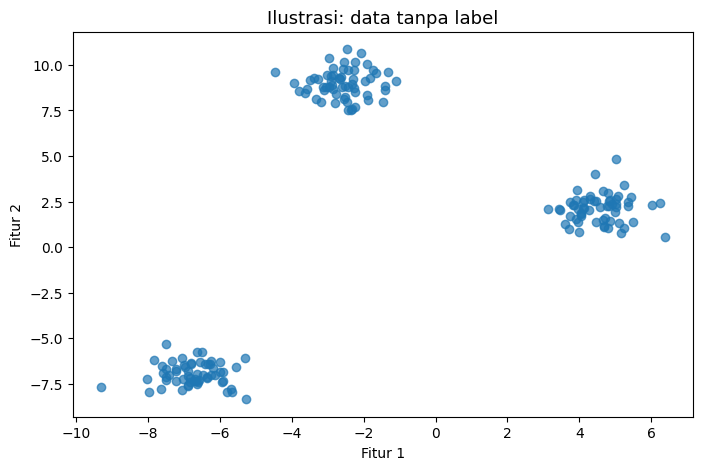

In [ ]:
from sklearn.datasets import make_blobs

X_demo, _ = make_blobs(n_samples=180, centers=3, cluster_std=0.75, random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(X_demo[:, 0], X_demo[:, 1], alpha=0.7)
plt.title("Ilustrasi: data tanpa label")
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.show()

### Cara membaca gambar

Kita **belum tahu nama cluster**. Yang kita lihat hanya bahwa beberapa titik relatif dekat satu sama lain. Inilah ide dasar unsupervised learning: mencari struktur/pola tanpa target `y`.

# CASE STUDY — CUSTOMER SEGMENTATION

Kita menggunakan data **Wholesale Customers** yang berisi pengeluaran pelanggan pada beberapa kategori produk. Dataset tersedia sebagai CSV publik di GitHub dan dapat dibaca langsung menggunakan `pandas`.

In [2]:
DATA_PATH = "/content/drive/MyDrive/PJJ Data Analitic/CC GENERAL.csv"

try:
    data = pd.read_csv(DATA_PATH)
except Exception as e:
    raise RuntimeError(
        "Gagal membaca dataset dari Google Drive. Periksa kembali lokasi path."
    ) from e

data.head()

RuntimeError: Gagal membaca dataset dari Google Drive. Periksa kembali lokasi path.

## 2.1 Mengenali dataset

Jangan langsung menjalankan algoritma. Pertama jawab tiga hal:

1. **Satu baris mewakili apa?** → satu pelanggan/unit analisis.
2. **Fitur apa yang menjelaskan unit tersebut?** → pengeluaran kategori produk.
3. **Apa yang ingin kita cari?** → kelompok pelanggan dengan pola belanja yang mirip.

In [6]:
data.info()
print("\nMissing value per kolom:")
print(data.isna().sum())
print("\nShape:", data.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [7]:
data['CREDIT_LIMIT'] = data['CREDIT_LIMIT'].fillna(
    data['CREDIT_LIMIT'].median()
)

data['MINIMUM_PAYMENTS'] = data['MINIMUM_PAYMENTS'].fillna(
    data['MINIMUM_PAYMENTS'].median()
)

In [8]:
data.info()
print("\nMissing value per kolom:")
print(data.isna().sum())
print("\nShape:", data.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [9]:
spend_cols = [
    "PURCHASES",
    "ONEOFF_PURCHASES",
    "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE",
    "PAYMENTS",
    "MINIMUM_PAYMENTS"
]

data[spend_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PAYMENTS,8950.0,1733.143852,2895.063757,0.000000,383.276166,856.901546,1901.134317,50721.48336
MINIMUM_PAYMENTS,8950.0,844.906767,2332.792322,0.019163,170.857654,312.343947,788.713501,76406.20752


## 2.2 Memilih fitur

`Channel` dan `Region` kita simpan sebagai informasi konteks, tetapi **tidak digunakan untuk membentuk cluster**. Untuk latihan ini, kita ingin mengelompokkan pelanggan berdasarkan pola pengeluaran enam kategori produk.

In [10]:
X_raw = data[spend_cols].copy()
X_raw.head()

,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PAYMENTS,MINIMUM_PAYMENTS
0,95.40,0.00,95.4,0.000000,201.802084,139.509787
1,0.00,0.00,0.0,6442.945483,4103.032597,1072.340217
2,773.17,773.17,0.0,0.000000,622.066742,627.284787
3,1499.00,1499.00,0.0,205.788017,0.000000,312.343947
4,16.00,16.00,0.0,0.000000,678.334763,244.791237


## 3. Preprocessing — mengapa perlu scaling?

K-Means dan banyak algoritma berbasis jarak sensitif terhadap skala fitur. Misalnya satu fitur memiliki nilai ribuan, sedangkan fitur lain puluhan; fitur berskala besar dapat “mendominasi” jarak.

**StandardScaler** mengubah setiap fitur sehingga secara umum memiliki mean ≈ 0 dan standar deviasi ≈ 1.

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

X_scaled_df = pd.DataFrame(X_scaled, columns=spend_cols)
X_scaled_df.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
PURCHASES,3.175610e-18,1.000056,-0.469552,22.483510
ONEOFF_PURCHASES,-6.033659e-17,1.000056,-0.356934,24.201066
INSTALLMENTS_PURCHASES,3.175610e-17,1.000056,-0.454576,24.426889
CASH_ADVANCE,-6.351220e-18,1.000056,-0.466786,22.011117
PAYMENTS,-2.540488e-17,1.000056,-0.598688,16.922279
MINIMUM_PAYMENTS,1.270244e-17,1.000056,-0.362199,32.392735


In [12]:
X_scaled_df

,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PAYMENTS,MINIMUM_PAYMENTS
0,-0.424900,-0.356934,-0.349079,-0.466786,-0.528979,-0.302400
1,-0.469552,-0.356934,-0.454576,2.605605,0.818642,0.097500
2,-0.107668,0.108889,-0.454576,-0.466786,-0.383805,-0.093293
3,0.232058,0.546189,-0.454576,-0.368653,-0.598688,-0.228307
4,-0.462063,-0.347294,-0.454576,-0.466786,-0.364368,-0.257266
...,...,...,...,...,...,...
8945,-0.333293,-0.356934,-0.132643,-0.466786,-0.486217,-0.341250
8946,-0.329136,-0.356934,-0.122823,-0.466786,-0.503396,-0.228307
8947,-0.401965,-0.356934,-0.294893,-0.466786,-0.570615,-0.326875
8948,-0.469552,-0.356934,-0.454576,-0.449352,-0.580536,-0.338305


> **Catatan penting:** scaling bukan selalu wajib. Kebutuhannya bergantung pada algoritma dan skala fitur. Untuk algoritma berbasis jarak seperti K-Means/DBSCAN, scaling sering menjadi langkah penting.

# 4. K-MEANS

### Intuisi sederhana

K-Means mengelompokkan data point berdasarkan jarak antar data dengan centroid. Inisiasi centroid akan dilakukan secara random dengan jumlah sesuai dengan nilai K. Titik centroid pada satu cluster akan bergeser/diupdate berdasarkan titik mean dari datapoint yang dikelompokan kedalam cluster tersebut.

Proses pengelompokan dan pergeseran titik centroid dilakukan secara iteratif hingga titik centroid tidak ada yang bergeser atau jumlah iterasi maksimal telah terlampaui

kelemahan K-means adalah kesulitan untuk menentukan jumlah K yang paling baik.

K-Means bekerja berulang kali:

1. tentukan jumlah cluster `K`,
2. tetapkan titik ke centroid terdekat,
3. hitung ulang centroid,
4. ulangi sampai pembagian cukup stabil.

**K-Means membutuhkan kita menentukan `K`.**

![image.png](attachment:image.png)

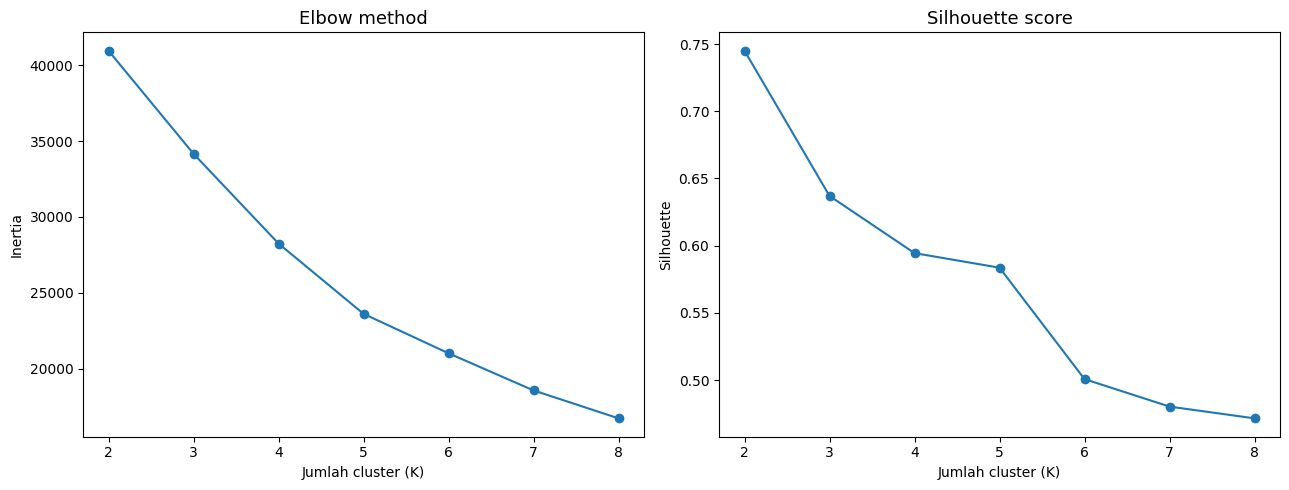

In [13]:
k_values = range(2, 9)
inertia = []
silhouette = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled_df)
    inertia.append(model.inertia_)
    silhouette.append(silhouette_score(X_scaled_df, labels))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(list(k_values), inertia, marker="o")
ax[0].set_title("Elbow method")
ax[0].set_xlabel("Jumlah cluster (K)")
ax[0].set_ylabel("Inertia")

ax[1].plot(list(k_values), silhouette, marker="o")
ax[1].set_title("Silhouette score")
ax[1].set_xlabel("Jumlah cluster (K)")
ax[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

### Membaca dua ukuran evaluasi

- **Inertia:** makin kecil makin baik, tetapi hampir selalu turun ketika `K` bertambah. Karena itu kita mencari “elbow”.
- **Silhouette:** semakin mendekati 1 secara umum menunjukkan cluster lebih terpisah dan kompak; nilai dekat 0 menunjukkan overlap; nilai negatif dapat mengindikasikan pembagian yang kurang baik.

> Jangan memperlakukan elbow/silhouette sebagai “jawaban otomatis”. Gunakan keduanya sebagai **bukti pendukung**, lalu cek apakah hasil cluster masuk akal secara substantif.

## 4.1 Membentuk model final

Untuk latihan kita pilih `K` berdasarkan kombinasi grafik di atas. Agar peserta bisa bereksperimen, angka `K` sengaja diletakkan di satu tempat.

In [14]:
K_FINAL = 5

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
cluster_label = kmeans.fit_predict(X_scaled_df)

data_clustered = data.copy()
data_clustered["cluster"] = cluster_label

print("Jumlah anggota setiap cluster:")
print(data_clustered["cluster"].value_counts().sort_index())

Jumlah anggota setiap cluster:
cluster
0      25
1    7428
2     750
3     693
4      54
Name: count, dtype: int64


## 5. Visualisasi cluster dengan PCA

Enam fitur sulit dilihat sekaligus. **PCA digunakan di sini terutama sebagai alat visualisasi**: enam dimensi kita proyeksikan menjadi dua dimensi.

> PCA tidak “membuat cluster”. Cluster sudah dibentuk K-Means pada data yang diskalakan. PCA membantu kita melihat hasilnya.

In [15]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_df)

pca_df = pd.DataFrame(X_pca, columns=["PCA1", "PCA2"])
pca_df["cluster"] = cluster_label

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.46904089 0.21788945]
Total: 0.6869303362596761


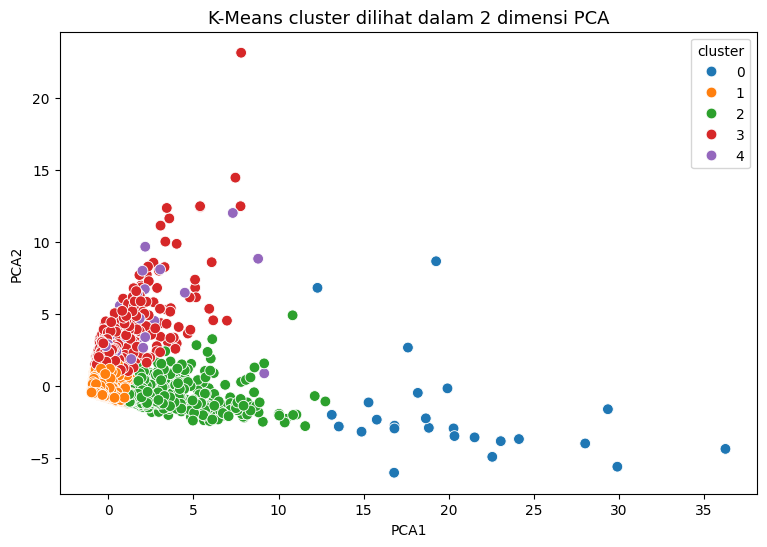

In [16]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=pca_df, x="PCA1", y="PCA2", hue="cluster", palette="tab10", s=60)
plt.title("K-Means cluster dilihat dalam 2 dimensi PCA")
plt.show()

## 6. Cluster profiling — bagian yang paling penting

Label `cluster = 0, 1, 2, ...` **tidak punya arti substantif secara otomatis**. Tugas analis adalah melihat karakteristik tiap cluster lalu memberi nama/profil yang masuk akal.

In [17]:
profile_mean = data_clustered.groupby("cluster")[spend_cols].mean().round(0)
profile_mean

,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PAYMENTS,MINIMUM_PAYMENTS
cluster,,,,,,
0,27085.0,21002.0,6083.0,1488.0,27159.0,3202.0
1,559.0,305.0,255.0,535.0,993.0,574.0
2,4963.0,3030.0,1935.0,439.0,4691.0,1152.0
3,542.0,335.0,207.0,6277.0,5540.0,1588.0
4,960.0,185.0,775.0,1310.0,1772.0,23288.0


In [18]:
# Agar perbandingan antar-cluster lebih mudah dibaca, bandingkan dengan rata-rata keseluruhan.
overall_mean = data_clustered[spend_cols].mean()
profile_index = (profile_mean / overall_mean * 100).round(0)

print("Index 100 = rata-rata seluruh pelanggan")
profile_index

Index 100 = rata-rata seluruh pelanggan


,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PAYMENTS,MINIMUM_PAYMENTS
cluster,,,,,,
0,2700.0,3545.0,1480.0,152.0,1567.0,379.0
1,56.0,51.0,62.0,55.0,57.0,68.0
2,495.0,511.0,471.0,45.0,271.0,136.0
3,54.0,57.0,50.0,641.0,320.0,188.0
4,96.0,31.0,189.0,134.0,102.0,2756.0


### Contoh cara menyampaikan insight

> “Cluster A relatif tinggi pada Grocery dan Detergents/Paper, tetapi lebih rendah pada Frozen. Ini dapat dibaca sebagai kelompok pelanggan dengan pola belanja **groceries-oriented**.”

Hindari kalimat seperti “algoritma menemukan pelanggan terbaik” sebelum ada konteks bisnis yang mendukung definisi “terbaik”.

## 7. Validasi sederhana dan interpretasi

Kita cek lagi silhouette score untuk model final.

In [19]:
final_silhouette = silhouette_score(X_scaled_df, cluster_label)
print(f"Silhouette score model final: {final_silhouette:.3f}")

Silhouette score model final: 0.584


## 8. Extension: DBSCAN (opsional)

DBSCAN berbeda dari K-Means karena berbasis **kepadatan (density)** dan dapat memberi label `-1` untuk titik yang dianggap noise. Ini berguna ketika kita mencurigai adanya observasi yang sangat berbeda dari kelompok umum.

DBSCAN mengelompokan data point berdasarkan kerapatan (density) antara satu data point dengan yang lainnya. Jumlah cluster yang dihasilkan akan secara otomatis ditentukan berdasarkan kerapatan data.

hyperparameter yang dapat ditune antara lain
- eps = mengkonfigurasi seberapa jauh jarak data untuk dapat dikelompokkan dalam satu cluster
- min_samples = mengkonfigurasi seberapa banyak data point yang harus dekat (rapat) untuk dapat dijadikan satu cluster

hasil cluster DBSCAN, akan menghasilkan data point yang berlabel -1 yang maksudnya adalah datapoint tersebut dianggap sebagai noise dan tidak dikelompokan ke dalam cluster manapun.

Kelemahan dari DBSCAN adalah jika datapoint tersebar, tidak akan ada cluster yang dihasilkan walaupun dapat terlihat sebagai satu cluster

Untuk kelas dengan waktu terbatas, cukup pahami tiga konsep: `eps`, `min_samples`, dan `noise (-1)`. Tidak perlu melakukan tuning DBSCAN secara mendalam.

![image.png](attachment:image.png)

In [20]:
dbscan = DBSCAN(eps=1.8, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled_df)
print("Label DBSCAN:")
print(pd.Series(db_labels).value_counts().sort_index())

Label DBSCAN:
-1      99
 0    8846
 1       5
Name: count, dtype: int64


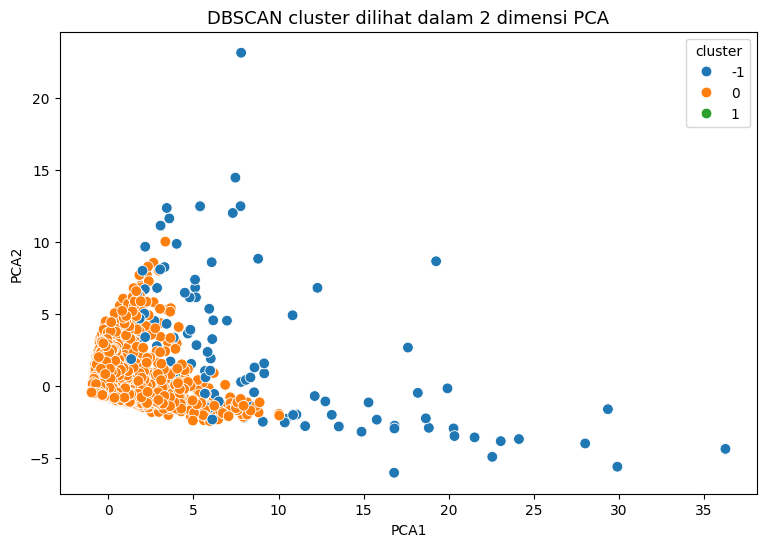

In [21]:
dbscan_pca_df = pd.DataFrame(X_pca, columns=["PCA1", "PCA2"])
dbscan_pca_df["cluster"] = db_labels

plt.figure(figsize=(9, 6))
sns.scatterplot(data=dbscan_pca_df, x="PCA1", y="PCA2", hue="cluster", palette="tab10", s=60)
plt.title("DBSCAN cluster dilihat dalam 2 dimensi PCA")
plt.show()

In [22]:
dbscan_pca_df

,PCA1,PCA2,cluster
0,-0.892488,-0.459753,0
1,-0.021120,2.658045,0
2,-0.423698,-0.456252,0
3,-0.112579,-0.647335,0
4,-0.870181,-0.356855,0
...,...,...,...
8945,-0.735221,-0.517471,0
8946,-0.723857,-0.487460,0
8947,-0.879286,-0.498740,0
8948,-0.988304,-0.448113,0


In [23]:
dbscan_pca_df.groupby('cluster')[['PCA1', 'PCA2']].describe()

PCA1                                                               \
          count      mean       std       min       25%       50%        75%   
cluster                                                                        
-1         99.0  9.400993  7.326812  1.341071  4.250916  6.486424  12.517462   
 0       8846.0 -0.107312  1.115455 -1.001020 -0.777069 -0.494199   0.097151   
 1          5.0  3.716822  0.474650  3.189839  3.264417  3.814043   4.057343   

                      PCA2                                                    \
               max   count      mean       std       min       25%       50%   
cluster                                                                        
-1       36.255772    99.0  2.506745  5.321769 -6.022591 -1.994118  1.536063   
 0       10.039963  8846.0 -0.028238  0.968388 -2.432708 -0.521315 -0.372856   
 1        4.258468     5.0  0.326000  0.468989 -0.357848  0.100402  0.504637   

                              
              75%        max  
cluster                       
-1       6.151634  23.135512  
 0       0.166967  10.023648  
 1       0.514900   0.867908

## 9. Key Takes Aways

**Clustering bukan sekadar menjalankan K-Means.**

1. Tetapkan unit analisis dan pertanyaan bisnis.
2. Pilih fitur yang benar-benar merepresentasikan kemiripan yang ingin dicari.
3. Lakukan preprocessing yang sesuai, terutama scaling untuk metode berbasis jarak.
4. Uji beberapa nilai `K`, jangan langsung memilih angka arbitrer.
5. Visualisasikan dan profilkan cluster.
6. Beri makna bisnis pada cluster; **label cluster sendiri bukan insight**.

### Visualisasi Algoritma Clustering
https://sindhulab.vercel.app/

## Referensi dataset

Dataset: **Wholesale Customers** (public GitHub CSV).

Raw CSV: `https://raw.githubusercontent.com/devdio/flyai_datasets/main/wholesale_customers_data.csv`

Referensi konsep: scikit-learn — KMeans, DBSCAN, StandardScaler, PCA, silhouette score.